In [ ]:
conda deactivate # if you use conde firstable deactive conda 

In [4]:
import numpy as np
import pandas as pd
import math
import numpy as np
import pandas as pd
import math
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.image as img
#import snap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
#import seaborn as sn
import math
import warnings
from collections import deque
from heapq import heappop, heappush
from itertools import count
from networkx.algorithms.shortest_paths.weighted import _weight_function
from networkx.utils import py_random_state
from networkx.utils.decorators import not_implemented_for
from numpy.random import randint
from numpy.random import rand
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import networkx.algorithms.isomorphism as iso
#import pymnet
#import matplotlib


In [7]:
C=nx.Graph()
C_Copy=nx.Graph()
E=nx.Graph()
F=nx.Graph()
C.add_weighted_edges_from([("t", "e", 1.0), ("e", "d", 1.0),("d", "a", 1.0), ("d", "c", 1.0),("a", "b", 1.0),("c", "b", 1.0), ("b","d",2.1)]) #
E.add_weighted_edges_from([(1,2, 1.0), (2, 3, 1.0),(3, 1, 1.0), (3, 4, 1.0),(4, "b", 1.0),(1, "t", 1.0)])
C_Copy.add_weighted_edges_from([(1,2, 1.0), (2, 3, 1.0),(3, 1, 1.0), (3, 4, 1.0)])
F.add_weighted_edges_from([(1,2, 1.0), (2, 3, 1.0),(3, 1, 1.0), (3, 4, 1.0),(4, "b", 1.0),(1, "t", 1.0)])

#nx.draw(C, with_labels=True, font_weight='bold')


# Drawn Metro layer 

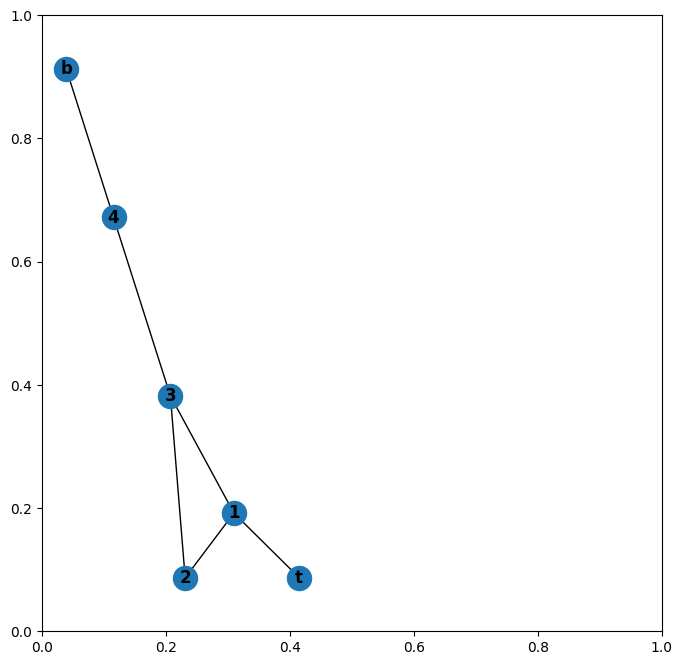

In [10]:
plt.subplots(figsize=(8,8))
plt.subplot(121)
nx.draw(E, with_labels=True, font_weight='bold')

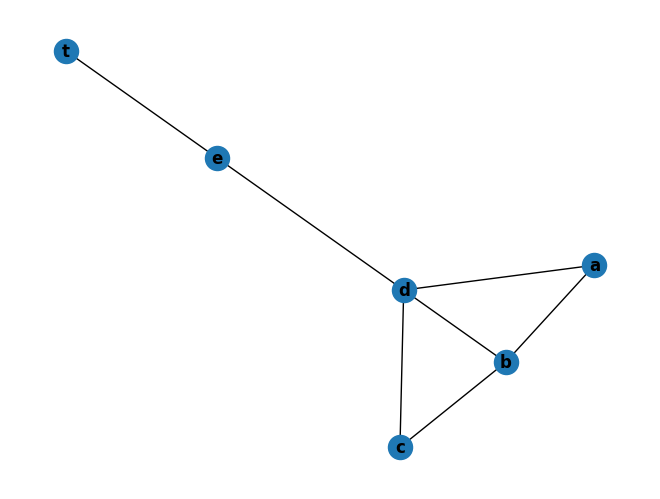

In [14]:
nx.draw(C, with_labels=True, font_weight='bold') # highhway layer 

In [ ]:
# Highway layer edge bettwenles value

In [19]:
layer1=nx.edge_betweenness_centrality(C,weight="weight")
print(layer1)

{('t', 'e'): 0.3333333333333333, ('e', 'd'): 0.5333333333333333, ('d', 'a'): 0.3333333333333333, ('d', 'c'): 0.3333333333333333, ('d', 'b'): 0.0, ('a', 'b'): 0.2, ('c', 'b'): 0.2}


In [ ]:
# Metro layer betweenles edge values

In [24]:
layer2=nx.edge_betweenness_centrality(E,weight="weight")
print(layer2)

{(1, 2): 0.13333333333333333, (1, 3): 0.4, (1, 't'): 0.3333333333333333, (2, 3): 0.2, (3, 4): 0.5333333333333333, (4, 'b'): 0.3333333333333333}


# Edge Betwenless centrality value for merged network layer 1 and layer 2

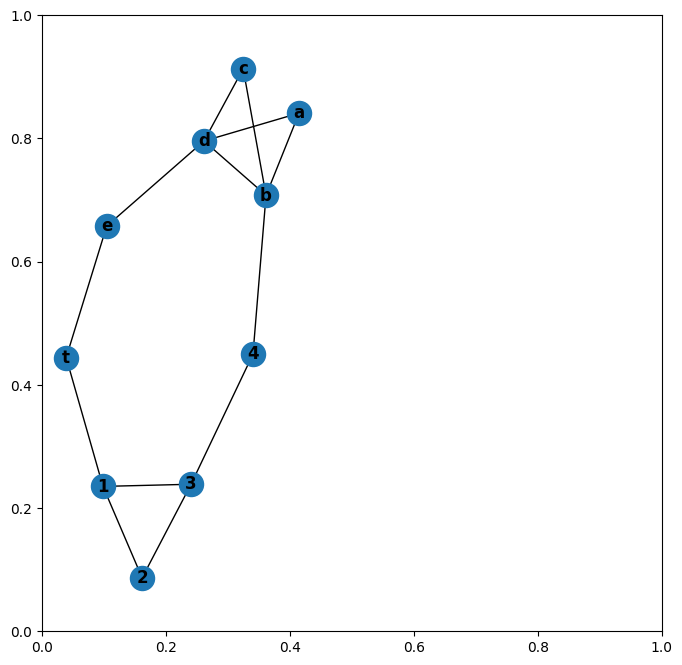

In [31]:
F.add_edges_from(C.edges)
plt.subplots(figsize=(8,8))
plt.subplot(121)
nx.draw(F, with_labels=True, font_weight='bold')


In [34]:
list(F.edges)

[(1, 2),
 (1, 3),
 (1, 't'),
 (2, 3),
 (3, 4),
 (4, 'b'),
 ('b', 'd'),
 ('b', 'a'),
 ('b', 'c'),
 ('t', 'e'),
 ('e', 'd'),
 ('d', 'a'),
 ('d', 'c')]

# from layer 1 to layer 2

In [71]:
sources= list(C.nodes())
targets= list(E.nodes())
layer1_2=nx.edge_betweenness_centrality_subset(F, sources, targets, normalized=False, weight="weight") # for nodes 

# from layer 2 to layer 1

In [73]:
sources= list(E.nodes())
targets= list(C.nodes())
layer2_1=nx.edge_betweenness_centrality_subset(F, sources, targets, normalized=False, weight="weight") # for node

In [75]:
layer1_2  #  Here, layer 1 and layer2 are calculated as if they were on a single surface. 
#The aim is to see the difference compared to the other method.Acording to one surface (layer 1 and layer 2 ) 

{(1, 2): 1.25,
 (1, 3): 2.5,
 (1, 't'): 4.75,
 (2, 3): 1.75,
 (3, 4): 5.25,
 (4, 'b'): 7.25,
 ('b', 'd'): 3.75,
 ('b', 'a'): 2.25,
 ('b', 'c'): 2.25,
 ('t', 'e'): 5.75,
 ('e', 'd'): 4.75,
 ('d', 'a'): 0.75,
 ('d', 'c'): 0.75}

In [77]:
layer2_1

{(1, 2): 1.25,
 (1, 3): 2.5,
 (1, 't'): 4.75,
 (2, 3): 1.75,
 (3, 4): 5.25,
 (4, 'b'): 7.25,
 ('b', 'd'): 3.75,
 ('b', 'a'): 2.25,
 ('b', 'c'): 2.25,
 ('t', 'e'): 5.75,
 ('e', 'd'): 4.75,
 ('d', 'a'): 0.75,
 ('d', 'c'): 0.75}

In [52]:
list1=list(layer1.keys())
list2=list(layer2.keys())
listgeneric=list(layer1_2.keys())

In [55]:
intra={}
inter={}

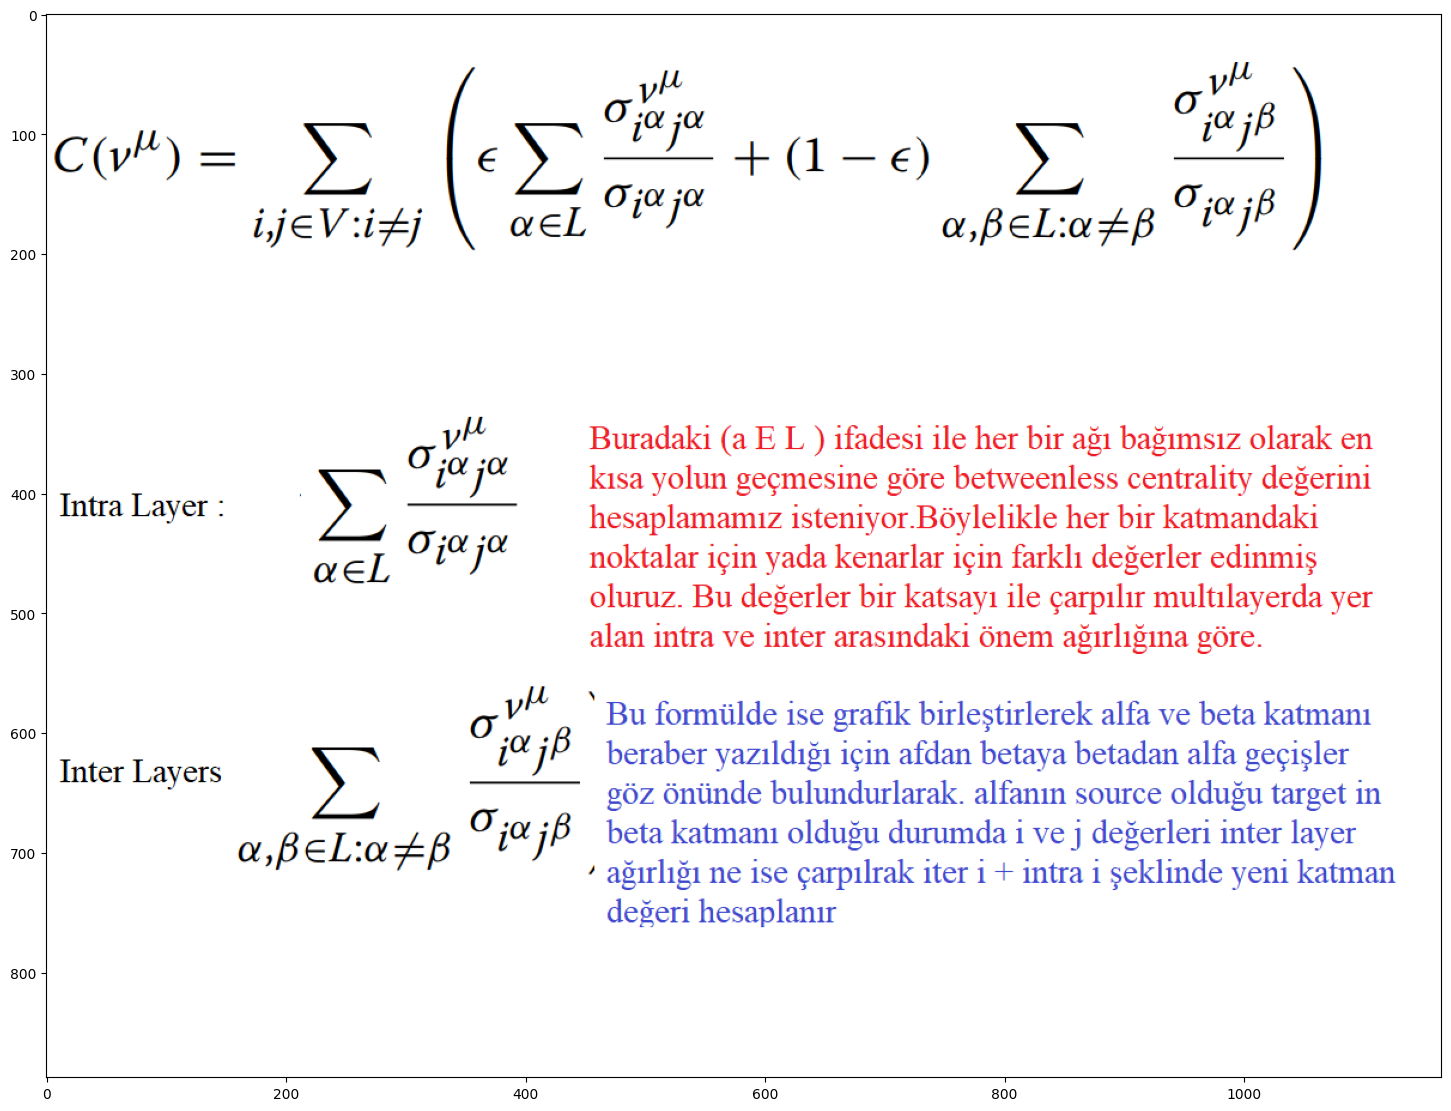

In [97]:
plt.subplots(figsize=(18,18))

img = mpimg.imread("multıbetw.png")
plt.imshow(img,)
plt.show()  # our formulation for multi layer 

In [58]:

alfa=0.8 # inter-layer transition rate
def MLB(layer1,layer2,layer1_2,alfa,F):
    list1=list(layer1.keys())
    list2=list(layer2.keys())
    listgeneric=list(layer1_2.keys())
    MLB={}
    for i in list(F.nodes): # merged network node list 
        for j in list(F.nodes): 

            if (i,j)  in listgeneric:# if edge i j exists in the combined layer list  
                if (i,j) in list1: # Multiply inter and intra if the edge exists in the first layer
                    MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer1[(i,j)])*alfa)
                if (j,i) in list1:  # Multiply by inter and intra if the inverse of the edge exists in the first layer
                    MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer1[(j,i)])*alfa)

                if (i,j) in list2: #  i,j multiply the layer merged with the second layer if the edge exists in the second layer  
                    MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer2[(i,j)])*alfa)
                if (j,i) in list2:#  j,i multiply the layer merged with the second layer if the edge exists in the second layer
                    MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer2[(j,i)])*alfa) 
    return MLB  

# According to the above formula, betweenles values of the network between metro and highway : ratio 0.8

In [65]:
MLB(layer1,layer2,layer1_2,alfa,F)

{(1, 2): 0.35666666666666663,
 (1, 3): 0.82,
 (1, 't'): 1.2166666666666663,
 (2, 3): 0.51,
 (3, 4): 1.4766666666666666,
 (4, 'b'): 1.7166666666666663,
 ('b', 'd'): 0.7499999999999998,
 ('b', 'a'): 0.6099999999999999,
 ('b', 'c'): 0.6099999999999999,
 ('t', 'e'): 1.4166666666666663,
 ('e', 'd'): 1.3766666666666665,
 ('d', 'a'): 0.41666666666666663,
 ('d', 'c'): 0.41666666666666663}

In [69]:
MLB(layer1,layer2,layer2_1,alfa,F)

{(1, 2): 0.35666666666666663,
 (1, 3): 0.82,
 (1, 't'): 1.2166666666666663,
 (2, 3): 0.51,
 (3, 4): 1.4766666666666666,
 (4, 'b'): 1.7166666666666663,
 ('b', 'd'): 0.7499999999999998,
 ('b', 'a'): 0.6099999999999999,
 ('b', 'c'): 0.6099999999999999,
 ('t', 'e'): 1.4166666666666663,
 ('e', 'd'): 1.3766666666666665,
 ('d', 'a'): 0.41666666666666663,
 ('d', 'c'): 0.41666666666666663}

In [80]:
list1=list(layer1.keys())
lise2=list(layer2.keys())
listgeneric=list(layer1_2.keys())

alfa=0.8 # BURAYA DİKKAT 
MLB= {}
for i in list(F.nodes): 
    for j in list(F.nodes): 

        if (i,j)  in listgeneric:  
            if (i,j) in list1: 
                MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer1[(i,j)])*alfa)
            if (j,i) in list1:  
                MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer1[(j,i)])*alfa)
            
            if (i,j) in list2: 
                MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer2[(i,j)])*alfa)
            if (j,i) in list2:
                MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer2[(j,i)])*alfa) 
MLB  

{(1, 2): 0.35666666666666663,
 (1, 3): 0.82,
 (1, 't'): 1.2166666666666663,
 (2, 3): 0.51,
 (3, 4): 1.4766666666666666,
 (4, 'b'): 1.7166666666666663,
 ('b', 'd'): 0.7499999999999998,
 ('b', 'a'): 0.6099999999999999,
 ('b', 'c'): 0.6099999999999999,
 ('t', 'e'): 1.4166666666666663,
 ('e', 'd'): 1.3766666666666665,
 ('d', 'a'): 0.41666666666666663,
 ('d', 'c'): 0.41666666666666663}

# All MULTILayer SD 

In [83]:
np.std(list(MLB.values())) 

np.float64(0.45620104683656704)

# Upper layer SD

In [86]:
H=[]
for h in list(C.edges):
    if h in list(MLB.keys()):
        H.append(MLB[h])
    elif (h[1],h[0]) in list(MLB.keys()):
        H.append(MLB[(h[1],h[0])])
np.std(H)

np.float64(0.39304843827438357)

# Lower layer SD 

In [88]:
M=[]
for h in list(E.edges):
    if h in list(MLB.keys()):
        M.append(MLB[h])
    elif (h[1],h[0]) in list(MLB.keys()):
        M.append(MLB[(h[1],h[0])])
np.std(M)

np.float64(0.4954101057099119)